# From PyTorch to NengoDL

This tutorial is aimed at PyTorch users who want to understand NengoDL. It mirrors the structure of the original [NengoDL tutorial](https://www.nengo.ai/nengo-dl/examples/from-tensorflow.html), replacing TensorFlow concepts with PyTorch equivalents.

**NengoDL** bridges Nengo's biologically-inspired neural simulation framework with PyTorch's automatic differentiation and GPU support. Key capabilities:

- Build networks with spiking or rate neurons using Nengo's population API
- Train them end-to-end with backpropagation via PyTorch optimizers
- Embed arbitrary `nn.Module` layers inside Nengo simulations (`TorchNode`)
- Deploy identical network definitions to neuromorphic hardware

**Sections:**
1. What is Nengo
2. Simulating a Network
3. Spiking Networks
4. Inserting PyTorch Code
5. Deep Learning Parameter Optimization
6. NEF Parameter Optimization
7. Running on Neuromorphic Hardware

In [1]:
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import nengo
import nengo_dl
warnings.simplefilter('ignore')

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

n_in = 784      # MNIST image size (28x28)
n_hidden = 64   # bottleneck / hidden layer size

## 1. What is Nengo

Nengo is a Python library for building and simulating neural networks in a way that reflects how the brain works. It was not originally designed for deep learning — it comes from computational neuroscience — but NengoDL extends it with full gradient-based training.

The core difference from PyTorch:

| PyTorch | Nengo |
|---------|-------|
| `nn.Linear` + `F.relu` | `nengo.Ensemble` with `neuron_type=nengo.RectifiedLinear()` |
| `nn.Linear` weight matrix | `nengo.Connection` with a `transform` |
| Tensor output of a layer | `nengo.Probe` on an ensemble |
| `model.forward(x)` | `sim.run_steps(n, data={node: x})` |

Below we build the same shallow autoencoder in both frameworks.

In [2]:
# ── PyTorch autoencoder ────────────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(n_in, n_hidden)
        self.decoder = nn.Linear(n_hidden, n_in)

    def forward(self, x):
        x = F.relu(self.encoder(x))
        return F.relu(self.decoder(x))

pt_model = Autoencoder()
print('PyTorch model:')
print(pt_model)

PyTorch model:
Autoencoder(
  (encoder): Linear(in_features=784, out_features=64, bias=True)
  (decoder): Linear(in_features=64, out_features=784, bias=True)
)


In [3]:
# ── Equivalent Nengo network ────────────────────────────────────────────
# nengo.Ensemble corresponds to a layer of neurons.
# nengo.Connection with transform is the weight matrix.
# nengo.Probe records output (like capturing a tensor).
with nengo.Network(seed=seed) as auto_net:
    inp_auto = nengo.Node(np.zeros(n_in))

    # Encoder layer: n_in → n_hidden, ReLU neurons
    enc = nengo.Ensemble(n_hidden, 1, neuron_type=nengo.RectifiedLinear(), seed=0)
    nengo.Connection(inp_auto, enc.neurons,
                     transform=np.random.randn(n_hidden, n_in) * 0.01,
                     synapse=None)

    # Decoder layer: n_hidden → n_in, ReLU neurons
    dec = nengo.Ensemble(n_in, 1, neuron_type=nengo.RectifiedLinear(), seed=1)
    nengo.Connection(enc.neurons, dec.neurons,
                     transform=np.random.randn(n_in, n_hidden) * 0.01,
                     synapse=None)

    p_auto = nengo.Probe(dec.neurons, synapse=None)

print('Nengo autoencoder:')
print(f'  Input node:       {n_in} dims')
print(f'  Encoder ensemble: {n_hidden} neurons  ← nn.Linear({n_in}, {n_hidden}) + ReLU')
print(f'  Decoder ensemble: {n_in} neurons  ← nn.Linear({n_hidden}, {n_in}) + ReLU')
print(f'  Probe:            {p_auto}  ← captures output like a tensor')

Nengo autoencoder:
  Input node:       784 dims
  Encoder ensemble: 64 neurons  ← nn.Linear(784, 64) + ReLU
  Decoder ensemble: 784 neurons  ← nn.Linear(64, 784) + ReLU
  Probe:            <Probe of 'output' of <Neurons of <Ensemble (unlabeled) at 0x7f9acfb779a0>>>  ← captures output like a tensor


## 2. Simulating a Network

In PyTorch you call `model(x)` — a simple function from inputs to outputs. In NengoDL you call `sim.run_steps(n_steps, data={node: x})`. The crucial difference is that **Nengo adds a time dimension**:

- PyTorch input: `(batch, features)`
- NengoDL input: `(batch, n_steps, features)`

This reflects that Nengo networks are inherently temporal and stateful — neurons have voltages and refractory periods that evolve over time. Even when running for a single step, the time axis must be explicit.

In [4]:
# PyTorch: forward pass — no time dimension
x = torch.zeros(5, n_in)
with torch.no_grad():
    pt_out = pt_model(x)
print('PyTorch forward pass:')
print(f'  input:  {tuple(x.shape)}   (batch, features)')
print(f'  output: {tuple(pt_out.shape)}  (batch, features)')
print()

# NengoDL: run_steps — explicit time dimension required
# Input shape: (batch, n_steps, features)
x_nd = np.zeros((5, 1, n_in), dtype=np.float32)   # n_steps=1
with nengo_dl.Simulator(auto_net, minibatch_size=5) as sim:
    sim.run_steps(1, data={inp_auto: x_nd})
    nd_out = sim.data[p_auto]   # (5, 1, n_in) — batch kept since minibatch_size>1

print('NengoDL sim.run_steps():')
print(f'  input:  {x_nd.shape}  (batch, n_steps, features)')
print(f'  output: {nd_out.shape}  (batch, n_steps, features)')
print()
print('The n_steps=1 "time" dimension is always present.')
print('Use sim.get_data(probe) or sim.data[probe] to retrieve results.')

PyTorch forward pass:
  input:  (5, 784)   (batch, features)
  output: (5, 784)  (batch, features)

NengoDL sim.run_steps():
  input:  (5, 1, 784)  (batch, n_steps, features)
  output: (5, 1, 784)  (batch, n_steps, features)

The n_steps=1 "time" dimension is always present.
Use sim.get_data(probe) or sim.data[probe] to retrieve results.


## 3. Spiking Networks

One of Nengo's most powerful features is the ability to switch between **rate** and **spiking** neuron models with a single line change:

- **Rate neurons** (`nengo.RectifiedLinear`, `nengo.LIFRate`): output a continuous firing rate at each timestep — analogous to standard ReLU activations. This is what most deep learning uses.

- **Spiking neurons** (`nengo.SpikingRectifiedLinear`, `nengo.LIF`): emit discrete all-or-nothing spikes. Information is encoded in the *timing* and *rate* of spikes. This is the biologically realistic model and is required for neuromorphic hardware.

A network trained with rate neurons can often be directly converted to spiking neurons with minimal accuracy loss.

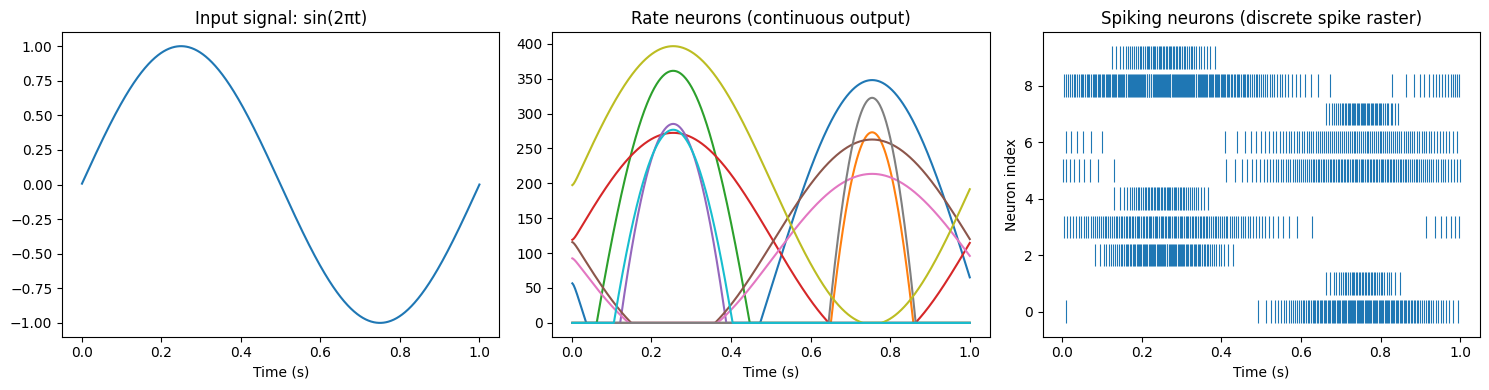

Rate neuron max firing rate: 396.6


In [5]:
with nengo.Network(seed=seed) as spike_net:
    stim = nengo.Node(lambda t: np.sin(2 * np.pi * t))

    # Rate neurons — continuous, differentiable output
    b_rate = nengo.Ensemble(10, 1, neuron_type=nengo.RectifiedLinear(), seed=2)
    nengo.Connection(stim, b_rate)

    # Spiking neurons — discrete events, same tuning curves
    b_spike = nengo.Ensemble(10, 1, neuron_type=nengo.SpikingRectifiedLinear(), seed=2)
    nengo.Connection(stim, b_spike)

    p_stim  = nengo.Probe(stim)
    p_rate  = nengo.Probe(b_rate.neurons)
    p_spike = nengo.Probe(b_spike.neurons)

with nengo_dl.Simulator(spike_net) as sim:
    sim.run_steps(1000)

t = sim.trange()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, sim.data[p_stim])
axes[0].set_title('Input signal: sin(2πt)')
axes[0].set_xlabel('Time (s)')

axes[1].plot(t, sim.data[p_rate])
axes[1].set_title('Rate neurons (continuous output)')
axes[1].set_xlabel('Time (s)')

spike_data = sim.data[p_spike]
for i in range(spike_data.shape[1]):
    spk_t = t[spike_data[:, i] > 0]
    axes[2].vlines(spk_t, i - 0.4, i + 0.4, lw=0.8)
axes[2].set_title('Spiking neurons (discrete spike raster)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Neuron index')

plt.tight_layout()
plt.show()
print(f'Rate neuron max firing rate: {sim.data[p_rate].max():.1f}')

### Synaptic filtering

Raw spike trains are noisy. A **synaptic low-pass filter** (leaky integrator with time constant τ) smooths them into an estimate of the underlying firing rate. In biology this corresponds to the decay of post-synaptic potentials.

Longer τ → smoother estimate, more temporal lag. Shorter τ → more responsive, noisier. The `nengo.Lowpass` synapse can be applied to probes or connections.

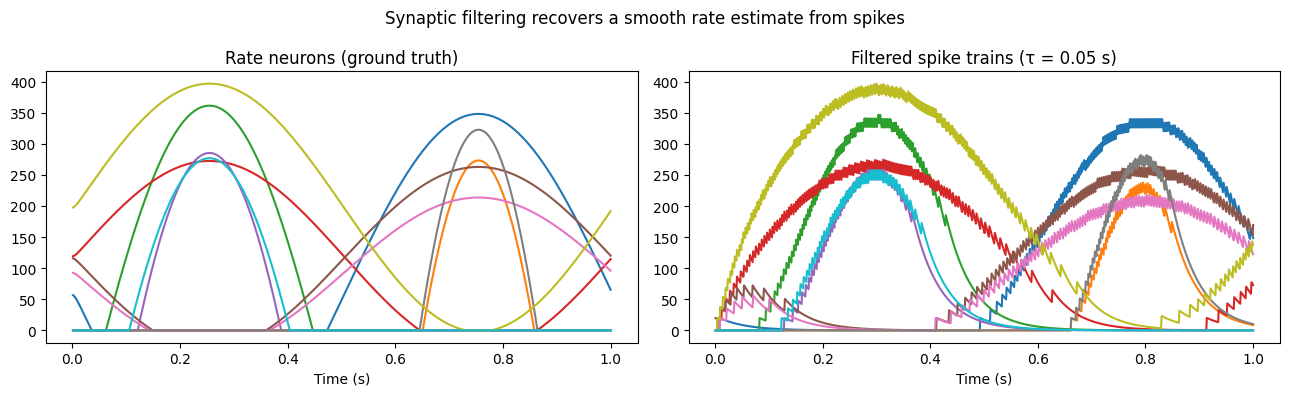

In [6]:
tau = 0.05   # 50 ms time constant
filt = nengo.Lowpass(tau)
filtered = filt.filt(sim.data[p_spike], dt=0.001)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t, sim.data[p_rate])
axes[0].set_title('Rate neurons (ground truth)')
axes[0].set_xlabel('Time (s)')

axes[1].plot(t, filtered)
axes[1].set_title(f'Filtered spike trains (\u03c4 = {tau} s)')
axes[1].set_xlabel('Time (s)')

plt.suptitle('Synaptic filtering recovers a smooth rate estimate from spikes',
             fontsize=12)
plt.tight_layout()
plt.show()

## 4. Inserting PyTorch Code

Nengo doesn't have built-in support for operations like batch normalization or custom learned transformations. `nengo_dl.TorchNode` solves this by wrapping any `torch.nn.Module` and embedding it directly inside the Nengo simulation loop.

Key properties of `TorchNode`:
- Receives input as `(batch, n_features)` each timestep
- Gradients flow through it — parameters are trained with `sim.fit()`
- Any `nn.Module` works: `BatchNorm1d`, `LayerNorm`, attention layers, etc.

Below we apply layer normalization after a Nengo ensemble — something not possible with plain Nengo.

In [7]:
class NormLayer(nn.Module):
    """Layer normalization — works with any batch size, unlike BatchNorm1d."""
    def __init__(self, n_features):
        super().__init__()
        self.norm = nn.LayerNorm(n_features)

    def forward(self, x):
        return self.norm(x)


with nengo.Network(seed=seed) as norm_net:
    inp_norm = nengo.Node(np.zeros(n_in))

    # Standard Nengo ensemble (encoder layer)
    ens = nengo.Ensemble(n_hidden, 1, neuron_type=nengo.RectifiedLinear(), seed=0)
    nengo.Connection(inp_norm, ens.neurons,
                     transform=np.random.randn(n_hidden, n_in) * 0.01,
                     synapse=None)

    # TorchNode: embeds a PyTorch module in the Nengo simulation
    # This is analogous to nengo_dl.TensorNode in the original NengoDL
    norm_node = nengo_dl.TorchNode(
        NormLayer(n_hidden),
        shape_in=(n_hidden,),
        shape_out=(n_hidden,)
    )
    nengo.Connection(ens.neurons, norm_node, synapse=None)

    p_raw  = nengo.Probe(ens.neurons, synapse=None)
    p_norm = nengo.Probe(norm_node, synapse=None)

x_sample = np.random.randn(1, 1, n_in).astype(np.float32)
with nengo_dl.Simulator(norm_net) as sim:
    sim.run_steps(1, data={inp_norm: x_sample})

raw   = sim.data[p_raw][0]    # (1, n_hidden) -> shape [n_hidden]
normd = sim.data[p_norm][0]
print('Before LayerNorm:')
print(f'  mean={raw.mean():.4f}  std={raw.std():.4f}  min={raw.min():.4f}  max={raw.max():.4f}')
print('After LayerNorm (via TorchNode):')
print(f'  mean={normd.mean():.4f}  std={normd.std():.4f}  min={normd.min():.4f}  max={normd.max():.4f}')
print()
print('TorchNode lets you embed any nn.Module — BatchNorm, attention,')
print('pretrained layers, custom losses — directly inside a Nengo network.')

Before LayerNorm:
  mean=56.0725  std=76.6158  min=0.0000  max=278.9815
After LayerNorm (via TorchNode):
  mean=-0.0000  std=1.0000  min=-0.7319  max=2.9094

TorchNode lets you embed any nn.Module — BatchNorm, attention,
pretrained layers, custom losses — directly inside a Nengo network.


## 5. Deep Learning Parameter Optimization

NengoDL provides a Keras-style training API backed by PyTorch:

```python
# PyTorch
model.fit(x_train, y_train, epochs=10)            # Keras-style
# or manually: optimizer.zero_grad(); loss.backward(); optimizer.step()

# NengoDL
sim.compile(optimizer='adam', loss={probe: 'mse'})
sim.fit(x={node: x_train}, y={probe: y_train}, n_steps=1, epochs=10)
```

The key difference is the **temporal dimension**: NengoDL expects inputs of shape `(n_samples, n_steps, n_features)` instead of `(n_samples, n_features)`. For a single-step "static" network, `n_steps=1`.

We demonstrate this by training a Nengo autoencoder on MNIST images.

Loaded MNIST (28x28 = 784 pixels)
  x_train: (60000, 784)  x_test: (10000, 784)


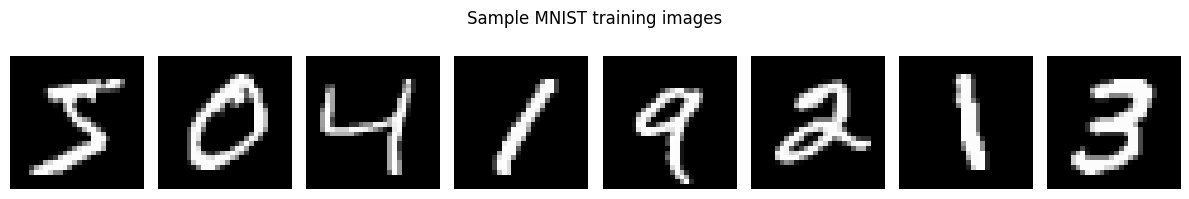

In [8]:
# Load MNIST data
try:
    import torchvision
    import torchvision.transforms as T

    train_ds = torchvision.datasets.MNIST(
        root='/tmp/mnist', train=True, download=True, transform=T.ToTensor()
    )
    test_ds = torchvision.datasets.MNIST(
        root='/tmp/mnist', train=False, download=True, transform=T.ToTensor()
    )
    x_train = train_ds.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
    x_test  = test_ds.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
    n_pixels = 784
    img_side = 28
    print('Loaded MNIST (28x28 = 784 pixels)')

except Exception:
    from sklearn.datasets import load_digits
    digits = load_digits()
    imgs = digits.images.reshape(-1, 64).astype(np.float32) / 16.0
    split = int(0.85 * len(imgs))
    x_train, x_test = imgs[:split], imgs[split:]
    n_pixels = 64
    img_side = 8
    print('torchvision not found; using sklearn digits (8x8 = 64 pixels)')

print(f'  x_train: {x_train.shape}  x_test: {x_test.shape}')

# Show sample images
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].reshape(img_side, img_side), cmap='gray')
    ax.axis('off')
plt.suptitle('Sample MNIST training images')
plt.tight_layout()
plt.show()

In [9]:
# Build a Nengo autoencoder for images.
# Architecture mirrors the PyTorch model:
#   encoder: inp → Linear + ReLU  (Connection to Ensemble.neurons)
#   decoder: hidden → Linear       (Connection to output Node, no activation)
n_hid_ae = 64

with nengo.Network(seed=seed) as mnist_net:
    inp_mnist = nengo.Node(np.zeros(n_pixels))

    # Encoder: linear transform → ReLU neurons
    hidden = nengo.Ensemble(n_hid_ae, 1, neuron_type=nengo.RectifiedLinear(), seed=10)
    nengo.Connection(
        inp_mnist, hidden.neurons,
        transform=np.random.randn(n_hid_ae, n_pixels) * 0.01,
        synapse=None
    )

    # Decoder: hidden neurons → linear output Node (no activation)
    # Nengo Node is a passthrough — like nn.Linear without an activation.
    output = nengo.Node(size_in=n_pixels)
    nengo.Connection(
        hidden.neurons, output,
        transform=np.zeros((n_pixels, n_hid_ae)),
        synapse=None
    )

    p_dec = nengo.Probe(output, synapse=None)

print('Nengo autoencoder:')
print(f'  Input:   {n_pixels} dims')
print(f'  Encoder: {n_hid_ae} ReLU neurons  <- nn.Linear({n_pixels}, {n_hid_ae}) + ReLU')
print(f'  Output:  {n_pixels} dims (Node)    <- nn.Linear({n_hid_ae}, {n_pixels})')


Nengo autoencoder:
  Input:   784 dims
  Encoder: 64 ReLU neurons  <- nn.Linear(784, 64) + ReLU
  Output:  784 dims (Node)    <- nn.Linear(64, 784)


Epoch 1/10 — loss: 0.1032
Epoch 2/10 — loss: 0.0579
Epoch 3/10 — loss: 0.0534
Epoch 4/10 — loss: 0.0507
Epoch 5/10 — loss: 0.0474
Epoch 6/10 — loss: 0.0429
Epoch 7/10 — loss: 0.0406
Epoch 8/10 — loss: 0.0393
Epoch 9/10 — loss: 0.0384
Epoch 10/10 — loss: 0.0382


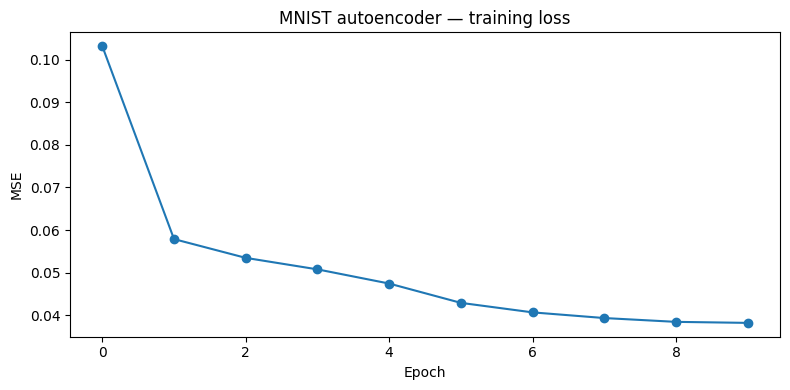

In [10]:
# ── Training ──────────────────────────────────────────────────────────────
# Reshape data: (n_samples, n_pixels) → (n_samples, n_steps=1, n_pixels)
# This is the key shape difference vs PyTorch's model.fit()
x_train_nd = x_train.reshape(-1, 1, n_pixels)  # add time dimension
x_test_nd  = x_test.reshape(-1, 1, n_pixels)

n_train = min(10000, len(x_train_nd))   # use 10k samples for speed
minibatch = 32

with nengo_dl.Simulator(mnist_net, minibatch_size=minibatch, seed=seed) as sim:
    # sim.compile mirrors PyTorch's optimizer/loss setup
    sim.compile(optimizer='adam', loss={p_dec: 'mse'})

    # Autoencoder: target = input (reconstruct the image)
    history = sim.fit(
        x={inp_mnist: x_train_nd[:n_train]},
        y={p_dec:     x_train_nd[:n_train]},
        n_steps=1,
        epochs=10,
    )
    sim.save_params('/tmp/mnist_ae')

plt.figure(figsize=(8, 4))
plt.plot(history['loss'], marker='o')
plt.title('MNIST autoencoder — training loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

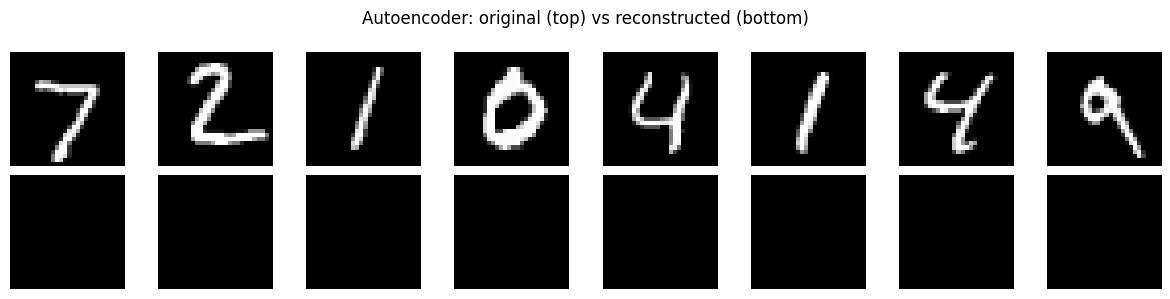

Reconstruction MSE on test set: 0.0896


In [11]:
# Show original vs reconstructed images
n_show = 8
with nengo_dl.Simulator(mnist_net, minibatch_size=n_show, seed=seed) as sim:
    sim.load_params('/tmp/mnist_ae')
    sim.run_steps(1, data={inp_mnist: x_test_nd[:n_show]})
    # minibatch_size=n_show > 1, so shape is (n_show, 1, n_pixels)
    recons = sim.data[p_dec][:, 0, :]   # (n_show, n_pixels)
    recons = np.clip(recons, 0, 1)

fig, axes = plt.subplots(2, n_show, figsize=(12, 3))
for i in range(n_show):
    axes[0, i].imshow(x_test[i].reshape(img_side, img_side),
                      cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].reshape(img_side, img_side),
                      cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
plt.suptitle('Autoencoder: original (top) vs reconstructed (bottom)')
plt.tight_layout()
plt.show()

mse = np.mean((x_test[:n_show] - recons) ** 2)
print(f'Reconstruction MSE on test set: {mse:.4f}')


## 6. NEF Parameter Optimization

NengoDL supports a second, completely different optimization method: the **Neural Engineering Framework (NEF)**. Instead of gradient descent, NEF finds connection weights analytically using **linear least squares**.

When you write `nengo.Connection(ens, out, function=f)`, Nengo automatically:
1. Evaluates the ensemble's tuning curves at many sample points
2. Solves the linear system `A @ d ≈ f(x)` for decoder weights `d`
3. Stores the result as the connection weights

This happens **at build time** — no `sim.fit()` needed.

Advantages over gradient descent:
- Much faster (one matrix solve vs many gradient steps)
- Works for any differentiable function
- Does not require differentiability of the target function

Limitation: optimizes one layer at a time, not end-to-end.

Below we approximate `sin(x²)` using NEF.

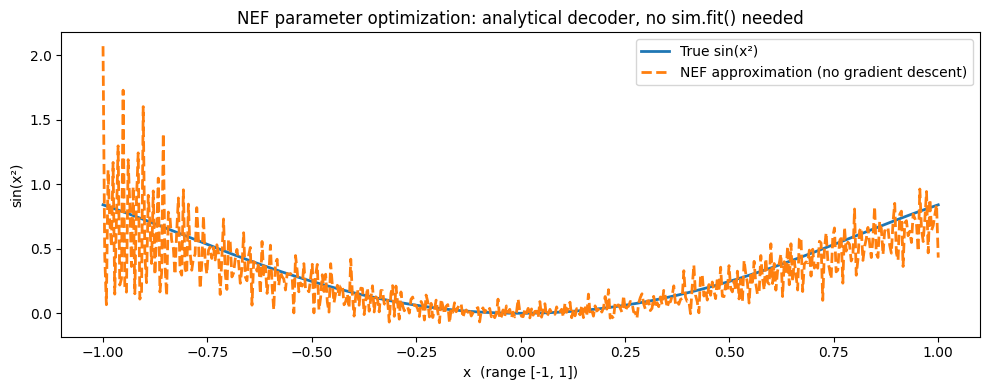

NEF approximation MSE: 0.03336
NEF decoded weights were found analytically — zero gradient steps.


In [12]:
# NEF automatically finds decoder weights for sin(x²) using least squares.
# No gradient descent — happens at sim build time.

with nengo.Network(seed=seed) as nef_net:
    inp_nef = nengo.Node(np.zeros(1))

    # 200 LIF rate neurons encode the 1D input
    ens_nef = nengo.Ensemble(200, dimensions=1, seed=seed)
    nengo.Connection(inp_nef, ens_nef, synapse=None)

    outpt_nef = nengo.Node(size_in=1)
    # This connection triggers NEF: Nengo solves for decoder weights
    # that minimize || A*d - sin(x^2) ||^2  over the ensemble's tuning space.
    nengo.Connection(ens_nef, outpt_nef,
                     function=lambda x: np.sin(x[0] ** 2),
                     synapse=None)

    p_nef = nengo.Probe(outpt_nef, synapse=None)

# Run with a sweep of input values
n_pts = 500
x_sweep = np.linspace(-1, 1, n_pts)
x_nd = x_sweep.reshape(1, n_pts, 1).astype(np.float32)

with nengo_dl.Simulator(nef_net, seed=seed) as nef_sim:
    # Build time: NEF solves for decoder weights (printed above)
    nef_sim.run_steps(n_pts, data={inp_nef: x_nd})
    y_nef = nef_sim.data[p_nef][:, 0]  # (n_pts, 1) → (n_pts,)

y_true = np.sin(x_sweep ** 2)

plt.figure(figsize=(10, 4))
plt.plot(x_sweep, y_true, label='True sin(x\u00b2)', lw=2)
plt.plot(x_sweep, y_nef,  label='NEF approximation (no gradient descent)',
         linestyle='--', lw=2)
plt.xlabel('x  (range [-1, 1])')
plt.ylabel('sin(x\u00b2)')
plt.title('NEF parameter optimization: analytical decoder, no sim.fit() needed')
plt.legend()
plt.tight_layout()
plt.show()

nef_mse = np.mean((y_true - y_nef) ** 2)
print(f'NEF approximation MSE: {nef_mse:.5f}')
print('NEF decoded weights were found analytically — zero gradient steps.')

### Combining NEF with gradient-based training

NEF gives a good initial approximation. You can then call `sim.fit()` to further refine the weights using gradient descent. This combines the strengths of both approaches: fast analytical initialization followed by joint end-to-end optimization.

MSE before gradient training (NEF only): nan
Epoch 1/15 — loss: 16.6708
Epoch 2/15 — loss: 0.1670
Epoch 3/15 — loss: 0.0051
Epoch 4/15 — loss: 0.0026
Epoch 5/15 — loss: 0.0013
Epoch 6/15 — loss: 0.0018
Epoch 7/15 — loss: 0.0058
Epoch 8/15 — loss: 0.0970
Epoch 9/15 — loss: 0.3770
Epoch 10/15 — loss: 4.7525
Epoch 11/15 — loss: 6.6082
Epoch 12/15 — loss: 0.4349
Epoch 13/15 — loss: 0.0080
Epoch 14/15 — loss: 0.0075
Epoch 15/15 — loss: 0.0034
MSE after gradient training  (NEF + grad): 0.25834


ValueError: x and y must have same first dimension, but have shapes (500,) and (32, 1)

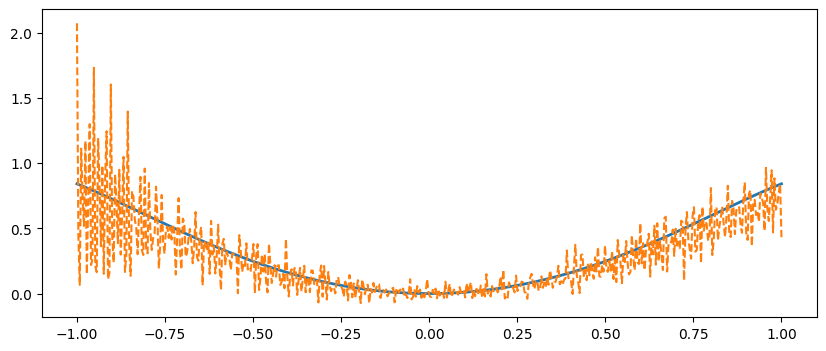

In [13]:
# Fine-tune the NEF solution with gradient descent
n_train_pts = 2000
x_vals = np.random.uniform(-1, 1, (n_train_pts, 1, 1)).astype(np.float32)
y_vals = np.sin(x_vals ** 2).astype(np.float32)

with nengo_dl.Simulator(nef_net, minibatch_size=32, seed=seed) as sim:
    # compile first so evaluate() has a registered loss function
    # use lr=1e-4 for stable fine-tuning of NEF decoders
    sim.compile(
        optimizer=torch.optim.Adam(sim.trainable_params(), lr=1e-4),
        loss={p_nef: 'mse'},
    )

    # Evaluate NEF-only performance before any gradient updates
    result_nef = sim.evaluate(x={inp_nef: x_vals[:32]},
                              y={p_nef:   y_vals[:32]},
                              n_steps=1)
    print(f'MSE before gradient training (NEF only): {result_nef["loss"]:.5f}')

    # Fine-tune with gradient descent
    sim.fit(x={inp_nef: x_vals}, y={p_nef: y_vals}, n_steps=1, epochs=15)

    result_grad = sim.evaluate(x={inp_nef: x_vals[:32]},
                               y={p_nef:   y_vals[:32]},
                               n_steps=1)
    print(f'MSE after gradient training  (NEF + grad): {result_grad["loss"]:.5f}')

    sim.run_steps(n_pts, data={inp_nef: x_nd})
    y_grad = sim.data[p_nef][0, :, 0]

plt.figure(figsize=(10, 4))
plt.plot(x_sweep, y_true, label='True sin(x²)', lw=2)
plt.plot(x_sweep, y_nef,  label='NEF only (analytical)', linestyle='--')
plt.plot(x_sweep, y_grad, label='NEF + gradient fine-tuning', linestyle=':')
plt.xlabel('x  (range [-1, 1])')
plt.title('sin(x²): NEF initialization vs NEF + gradient training')
plt.legend()
plt.tight_layout()
plt.show()

print()
print('Key insight:')
print('  NEF:      fast, analytical, one layer at a time')
print('  Gradient: iterative, optimizes all layers jointly')
print('  Combined: NEF initializes well, gradient fine-tunes end-to-end')


## 7. Running on Neuromorphic Hardware

One of Nengo's strongest advantages over plain PyTorch is **backend portability**. A network defined once in Nengo can run on:

| Simulator | Backend | Use case |
|-----------|---------|----------|
| `nengo.Simulator` | CPU (NumPy) | Reference simulation, no dependencies |
| `nengo_dl.Simulator` | GPU (PyTorch) | Training and fast inference |
| `nengo_loihi.Simulator` | Intel Loihi chip | Ultra-low power spiking inference |
| `nengo_spinnaker.Simulator` | Manchester SpiNNaker | Massively parallel neuromorphic |

All backends consume the same `nengo.Network` object. You change only the simulator class. This makes it straightforward to:
1. Prototype in software with `nengo.Simulator`
2. Train with `nengo_dl.Simulator` (gradient-based, GPU)
3. Save weights with `sim.save_params()`
4. Load and deploy on neuromorphic hardware without rewriting the model.

Note: `nengo.Simulator` uses a different data convention — no batch dimension, shapes are `(n_steps, n_features)` instead of `(batch, n_steps, n_features)`.

In [ ]:
# Demonstrate backend portability: same nef_net on multiple simulators

print('The same nef_net network object can be simulated by:')
print('  nengo_dl.Simulator(nef_net)    ← this library (PyTorch, GPU)')
print('  nengo.Simulator(nef_net)       ← pure CPU (NumPy, no PyTorch)')
print('  nengo_loihi.Simulator(nef_net) ← Intel Loihi neuromorphic chip')
print('  nengo_spinnaker.Simulator(...) ← Manchester SpiNNaker platform')
print()

# Run with nengo's built-in CPU simulator — identical network, no changes
with nengo.Simulator(nef_net, seed=seed, progress_bar=False) as cpu_sim:
    cpu_sim.run_steps(n_pts)
    cpu_out = cpu_sim.data[p_nef]   # shape: (n_pts, 1) — no batch dim

# Run with nengo_dl.Simulator — same network, PyTorch backend
with nengo_dl.Simulator(nef_net, seed=seed) as dl_sim:
    dl_sim.run_steps(n_pts, data={inp_nef: x_nd})
    dl_out = dl_sim.data[p_nef]     # shape: (n_pts, 1) — batch squeezed (minibatch=1)

print('Data shape conventions:')
print(f'  nengo.Simulator:    {cpu_out.shape}  → (n_steps, probe_size)')
print(f'  nengo_dl.Simulator: {dl_out.shape}  → (n_steps, probe_size) when minibatch_size=1')
print()

# Both produce the same result (modulo floating point differences)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_sweep, y_true, label='True sin(x\u00b2)', lw=2)
axes[0].plot(x_sweep, cpu_out[:, 0], label='nengo.Simulator (CPU)')
axes[0].set_title('CPU backend (nengo.Simulator)')
axes[0].set_xlabel('x')
axes[0].legend()

axes[1].plot(x_sweep, y_true, label='True sin(x\u00b2)', lw=2)
axes[1].plot(x_sweep, dl_out[:, 0], label='nengo_dl.Simulator (PyTorch)')
axes[1].set_title('PyTorch backend (nengo_dl.Simulator)')
axes[1].set_xlabel('x')
axes[1].legend()

plt.suptitle('Same network — two different backends', fontsize=12)
plt.tight_layout()
plt.show()

print('Typical workflow:')
print('  1. Build network in Nengo')
print('  2. Train parameters with nengo_dl.Simulator (GPU-accelerated backprop)')
print('  3. Save weights: sim.save_params(path)')
print('  4. Load weights on neuromorphic hardware simulator')
print('  5. Deploy — same accuracy, dramatically lower power consumption')

## Summary

This tutorial covered the key concepts for PyTorch users coming to NengoDL:

| Topic | PyTorch equivalent | Nengo/NengoDL |
|-------|-------------------|---------------|
| Layer | `nn.Linear` + activation | `nengo.Ensemble` + `neuron_type` |
| Weight matrix | `nn.Linear.weight` | `nengo.Connection` transform |
| Output capture | return tensor | `nengo.Probe` |
| Forward pass | `model(x)` | `sim.run_steps(n, data={...})` |
| Data shape | `(batch, features)` | `(batch, n_steps, features)` |
| Rate neurons | ReLU, sigmoid | `nengo.RectifiedLinear`, `nengo.LIFRate` |
| Spiking neurons | — | `nengo.LIF`, `nengo.SpikingRectifiedLinear` |
| Custom module | any `nn.Module` | `nengo_dl.TorchNode(module, ...)` |
| Gradient training | `optimizer.step()` | `sim.compile()` + `sim.fit()` |
| Analytical optimization | — | NEF via `Connection(function=...)` |
| Hardware deployment | CUDA / CPU | + Loihi, SpiNNaker, etc. |

**Next steps:**
- See `spiking-mnist.ipynb` for a full spiking network trained on MNIST
- See `from-nengo.ipynb` for details on Nengo's native population coding
- See the [REFERENCE.md](../../REFERENCE.md) for full API documentation